In [1]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import TwoSlopeNorm, Normalize
plt.style.use('custom_paper')

In [2]:
G = 1
M = 1

In [3]:
def compute_params(a, r0, e, z0, omega, theta0):
    dphi = theta0 - omega
    cosd = np.cos(dphi)
    sind = np.sin(dphi)
    k1 = (1 + e)**2 * (a**2 * (1 - e)**2 + r0**2 + z0**2 - 2 * a * (1 - e) * r0 * cosd)
    k2 = -4 * a * (1 - e) * (1 + e)**2 * r0 * sind
    k3 = 2 * (-1 + e**2) * (a**2 * (-1 + e**2) - r0**2 - z0**2 - 2 * a * e * r0 * cosd)
    k4 = -4 * a * (1 - e)**2 * (1 + e) * r0 * sind          # sign flipped
    k5 = (1 - e)**2 * (a**2 * (1 + e)**2 + r0**2 + z0**2 + 2 * a * (1 + e) * r0 * cosd)
    return dphi, k1, k2, k3, k4, k5    

def compute_roots(k1, k2, k3, k4, k5):
    coeffs = [k5, k4, k3, k2, k1]
    roots = np.roots(coeffs)
    q3 = next(r for r in roots if np.real(r) < 0 and np.imag(r) < 0)  # r1
    q2 = next(r for r in roots if np.real(r) < 0 and np.imag(r) > 0)  # r2
    q4 = next(r for r in roots if np.real(r) > 0 and np.imag(r) < 0)  # r3
    q1 = next(r for r in roots if np.real(r) > 0 and np.imag(r) > 0)  # r4
    return [q3, q2, q4, q1]

def compute_AB(roots):
    roots_sorted = sorted(roots, key=lambda z: (np.real(z), np.imag(z)))
    r1 = roots_sorted[0]
    r3 = roots_sorted[2]
    A1 = np.real(r1)
    B1 = np.abs(np.imag(r1))
    A2 = np.real(r3)
    B2 = np.abs(np.imag(r3))
    return [A1, B1, A2, B2]

def compute_vars(k1, k2, k3, k4, k5, r1, r2, r3, r4, e):
    R1 = r2*r3 + r1*r4
    R2 = np.sqrt((r1 - r3)*(r2 - r4))
    eta1 = 27*k2**4*k5**2 + 2*k2**3*(2*k4**3 - 9*k3*k4*k5) + 2*k1*k2*k4*(-9*k3*k4**2 + 40*k3**2*k5 + 96*k1*k5**2) + k2**2*(-k3**2*k4**2 + 4*k3**3*k5 + 6*k1*k4**2*k5 - 144*k1*k3*k5**2) + k1*(4*k3**3*k4**2 - 16*k3**4*k5 - 144*k1*k3*k4**2*k5 + 128*k1*k3**2*k5**2 + k1*(27*k4**4 - 256*k1*k5**3))
    eta2 = -9*k2**3*k5 + k2**2*k4*(k3 + 3*k5) - k1*k4*(4*k3**2 + 9*k4**2 + 48*k1*k5 - 32*k3*k5) + k2*k3*(k4**2 - 4*k3*k5) + k1*k2*(3*k4**2 + 16*(2*k3 - 3*k5)*k5)
    eta3 = 3*k2**3*k4 + 2*k1**2*(9*k4**2 - 8*k3*k5) + k3**2*(k4**2 - 4*k3*k5) + k2*(-14*k1*k3*k4 - 3*k4**3 + 14*k3*k4*k5) + 2*k1*(2*k3**3 - 3*k4**2*k5 + 8*k3*k5**2) - k2**2*(k3**2 + 6*k5*(-k1 + 3*k5))
    kappa1 = 3*(-1 + e)*k2**3*k4 + (1 + e)*k3**2*(k4**2 - 4*k3*k5) + 2*k1**2*(9*(-1 + e)*k4**2 + 8*(k3 - e*k3 - 4*k5)*k5) + 2*k1*(2*(-1 + e)*k3**3 - 3*k3*k4**2 + 8*k3**2*k5 - 3*(1 + e)*k4**2*k5 + 8*(1 + e)*k3*k5**2) + k2**2*(-((-1 + e)*k3**2) + 2*k4**2 - 6*k3*k5 - 6*k5*(k1 - e*k1 + 3*(1 + e)*k5)) + k2*k4*(-14*(-1 + e)*k1*k3 + 8*k1*k5 - (1 + e)*(3*k4**2 - 14*k3*k5))
    eta4 = 4*(k4**2*(k2**3 - 4*k1*k2*k3 + k2**2*k4 + 3*k1*(3*k1 - k3)*k4) + (-3*k2**3*k3 + k2**2*(k1 - 4*k3)*k4 + 4*k1*k3*(-8*k1 + 3*k3)*k4 + k1*k2*(12*k3**2 + k4**2))*k5 + (9*k2**3 - 32*k1*k2*k3 + 16*k1**2*(k2 + k4))*k5**2)
    eta5 = k4*(-k2**3*k3 + k1*k2**2*k4 + k2*k3*(4*k1*k3 + k4**2) - 3*k1*k4*(4*k1*k3 + 3*k4**2)) + (9*k2**4 + k2*(64*k1**2*k4 - 4*k3**2*k4) - k2**2*(44*k1*k3 + k4**2) + 4*k1*k3*(8*k1*k3 + 11*k4**2))*k5 - 4*(-3*k2**2*k3 + 8*k1*(4*k1**2 + k3**2 + 2*k2*k4))*k5**2 + 128*k1**2*k5**3
    kappa2 = k2**3*k4*((-1 + e)*k3 - 6*k5) - 9*(-1 + e)*k2**4*k5 + k2**2*((k1 - e*k1 - 2*k3)*k4**2 + (44*(-1 + e)*k1*k3 + 8*k3**2 + (1 + e)*k4**2)*k5 - 12*(4*k1 + k3 + e*k3)*k5**2) + k2*k4*(-64*(-1 + e)*k1**2*k5 + (1 + e)*k3*(-k4**2 + 4*k3*k5) + k1*(-4*(-1 + e)*k3**2 - 6*k4**2 + 48*k3*k5 + 64*(1 + e)*k5**2)) + k1*(128*(-1 + e)*k1**2*k5**2 + 4*k1*(3*(-1 + e)*k3*k4**2 - 4*(2*(-1 + e)*k3**2 + 3*k4**2)*k5 + 32*k3*k5**2 - 32*(1 + e)*k5**3) + (k4**2 - 4*k3*k5)*(9*(1 + e)*k4**2 + 8*k3*(k3 - (1 + e)*k5)))
    return R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2

def getallparams(params):
    a, r0, e, z0, omega, theta0 = params
    dphi, k1, k2, k3, k4, k5 = compute_params(*params)
    r1, r2, r3, r4 = compute_roots(k1, k2, k3, k4, k5)
    A1, B1, A2, B2 = compute_AB([r1, r2, r3, r4])
    R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = compute_vars(k1, k2, k3, k4, k5, r1, r2, r3, r4, e)
    return [a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2]


In [4]:
def jump_branch(n, s2, m):
    """
    Fully simplified form of the branch jump (no intermediate variables).
    Uses Carlson symmetric forms directly.
    """
    s = mp.sqrt(s2)
    RJ = 2 * mp.elliprj((m - 1)*s2, 0, m*s2, (m - n)*s2)
    RF = mp.elliprf(1 - s2, 1 - m*s2, 1)
    return -(n * s**3 / 3) * RJ - 2 * s * mp.re(RF)

def jump_pole(n,m):
    """
    Analytically simplified form (principal branches):
        i*pi*sqrt( n / ((n-1)*(n-m)) ).
    This is the exact simplification of the original expression *without* the `.real` chop.
    """
    return 1j*mp.pi*mp.sqrt(n/((n-1)*(n-m)))

In [5]:
def coeff(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return -4 / ((e-1)*np.sqrt(1+e)*np.sqrt(k5)*(-1-e+(e-1)*r1**2)*(-1-e+(e-1)*r2**2)*np.sqrt((r1-r3)*(r2-r4)))

def split1(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    rad = ((A1 - A2)**2 + B1**2)**2 + 2*(A1 - A2 - B1)*(A1 - A2 + B1)*B2**2 + B2**4
    return -(1/(2*(A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 - mp.sqrt(rad))

def split3(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    rad = ((A1 - A2)**2 + B1**2)**2 + 2*(A1 - A2 - B1)*(A1 - A2 + B1)*B2**2 + B2**4
    return -(1/(2*(A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 + mp.sqrt(rad))

def split2(allparams):
    (a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5,
     r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2) = allparams

    s = np.abs(e - 1.0)   
    t = np.abs(1.0 + e)   
    X = (A1*A1 + B1*B1) * s - t

    R = np.hypot(X, 2.0 * A1 * np.sqrt(s*t))

    denom = X + R
    return -(2.0 * A1 * t) / denom

def elliptic_wier_integrand(allparams, t, debug=False):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    s = ((r2 - r4) * (-(r1 - t))) / ((r1 - r4) * (-(r2 - t)))
    phi = mp.asin(mp.sqrt(s))

    m = -((r2 - r3) * (r1 - r4)) / ((-r1 + r3) * (r2 - r4))
    tau1 = mp.sqrt(1 + e)
    tau2 = mp.sqrt(e - 1)
    
    n1 = ((tau1 - tau2*r2) * (r1 - r4)) / ((tau1 - tau2*r1) * (r2 - r4))
    n2 = ((tau1 + tau2*r2) * (r1 - r4)) / ((tau1 + tau2*r1) * (r2 - r4))
    kF   = (tau2**2) * tau1 * (-tau1**2 + tau2**2 * r1**2) * (1 + r2**2)
    kPi1 = -e * (r1 - r2) * ( tau2 - tau1*r1 - (tau1 + tau2*r1)*r2 + e*( tau2 + tau1*r2 + r1*(tau1 + tau2*r2) ) )
    kPi2 =  e * (r1 - r2) * ( tau2 + tau1*r1 + tau1*r2 - tau2*r1*r2 + e*( tau2 - tau1*r1 - tau1*r2 + tau2*r1*r2 ) )
    
    F      = mp.ellipf(phi, m)
    Pi_n1  = mp.ellippi(n1, phi, m)
    Pi_n2  = mp.ellippi(n2, phi, m)
    
    t1 = split1(allparams)
    t2 = split3(allparams)
    t3 = split2(allparams)
    
    s2_t3 = ((r2 - r4) * (-(r1 - t3))) / ((r1 - r4) * (-(r2 - t3)))
    s2_t2 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t2)))
    s2_t1 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t1)))
    
    jump_val_F   = -2 * mp.ellipk(m).real
    jump2_n1     = jump_branch(n1, s2_t2, m)
    jump3_n1     = jump_pole(n1, m)
    jump2_n2     = jump_branch(n2, s2_t2, m)
    if t2 < t3:
        F_pw   = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3],[F, -F, F + jump_val_F, F + jump_val_F], default=np.nan)
        Pi1_pw = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3],[Pi_n1 + jump3_n1, -Pi_n1 + jump3_n1, Pi_n1 + jump2_n1 + jump3_n1, Pi_n1 + jump2_n1 + 2*jump3_n1], default=np.nan)
        Pi2_pw = np.select([t < t1, (t >= t1) & (t < t2), (t >= t2) & (t < t3), t >= t3],[Pi_n2, -Pi_n2, Pi_n2 + jump2_n2, Pi_n2 + jump2_n2], default=np.nan)
    if t3 < t2:
        F_pw   = np.select([t < t1, (t >= t1) & (t < t3), (t >= t3) & (t < t2), t >= t2],[F, -F, -F, F + jump_val_F], default=np.nan)
        Pi1_pw = np.select([t < t1, (t >= t1) & (t < t3), (t >= t3) & (t < t2), t >= t2],[Pi_n1 + jump3_n1, -Pi_n1 + jump3_n1, -Pi_n1, Pi_n1 + jump2_n1], default=np.nan)
        Pi2_pw = np.select([t < t1, (t >= t1) & (t < t3), (t >= t3) & (t < t2), t >= t2],[Pi_n2, -Pi_n2, -Pi_n2, Pi_n2 + jump2_n2], default=np.nan)
    C = coeff(allparams)
    piecewise_total = C * (kF * F_pw + kPi1 * Pi1_pw + kPi2 * Pi2_pw)
    return piecewise_total


In [6]:
def get_limits(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    c = coeff(allparams)
    
    phi = np.arcsin(np.sqrt((r2 - r4)/(r1 - r4))) 
    m = -((r2 - r3) * (r1 - r4)) / ((-r1 + r3) * (r2 - r4))
    tau1 = mp.sqrt(1 + e)    
    tau2 = mp.sqrt(e - 1)    
    n1 = ((tau1 - tau2*r2) * (r1 - r4)) / ((tau1 - tau2*r1) * (r2 - r4))
    n2 = ((tau1 + tau2*r2) * (r1 - r4)) / ((tau1 + tau2*r1) * (r2 - r4))
    kF   = (tau2**2) * tau1 * (-tau1**2 + tau2**2 * r1**2) * (1 + r2**2)
    kPi1 = -e * (r1 - r2) * ( tau2 - tau1*r1 - (tau1 + tau2*r1)*r2 + e*( tau2 + tau1*r2 + r1*(tau1 + tau2*r2) ) )
    kPi2 =  e * (r1 - r2) * ( tau2 + tau1*r1 + tau1*r2 - tau2*r1*r2 + e*( tau2 - tau1*r1 - tau1*r2 + tau2*r1*r2 ) )

    t1 = split1(allparams)
    t2 = split3(allparams)
    t3 = split2(allparams)

    s2_t3 = ((r2 - r4) * (-(r1 - t3))) / ((r1 - r4) * (-(r2 - t3)))
    s2_t2 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t2)))
    s2_t1 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t1)))  

    jump_val_F   = -2 * mp.ellipk(m).real
    jump2_n1     = jump_branch(n1, s2_t2, m) 
    jump3_n1     = jump_pole(n1,   m)
    jump2_n2     = jump_branch(n2, s2_t2, m) 
    
    F      = mp.ellipf(phi, m)
    Pi_n1  = mp.ellippi(n1, phi, m)
    Pi_n2  = mp.ellippi(n2, phi, m)    
    
    lower_limit = c*(kF*mp.ellipf(phi, m) + kPi1*(mp.ellippi(n1, phi, m) + jump3_n1) + kPi2*mp.ellippi(n2, phi, m))
    
    if t2 < t3:
        upper_limit = c*(kF*(mp.ellipf(phi, m)+jump_val_F) + kPi1*(mp.ellippi(n1, phi, m) + jump2_n1 + 2*jump3_n1) + kPi2*(mp.ellippi(n2, phi, m)+jump2_n2))
    if t3 < t2:
        upper_limit = c*(kF*(mp.ellipf(phi, m)+jump_val_F) + kPi1*(mp.ellippi(n1, phi, m) + jump2_n1) + kPi2*(mp.ellippi(n2, phi, m)+jump2_n2))
                     
    return lower_limit, upper_limit

In [7]:
def aXr(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return -(1/(a*k5*R2*eta1))*(-8*k5*R1*(r0*kappa1 + a*(e**2 - 1)*(eta3*np.cos(dphi) - eta2*np.sin(dphi))) + 4*(-r0*kappa2 + a*(e**2 - 1)*(eta5*np.cos(dphi) - eta4*np.sin(dphi))))

def aZr(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return (8*R2*(r0*kappa1 + a*(e**2 - 1)*eta3*np.cos(dphi) - a*(e**2 - 1)*eta2*np.sin(dphi)))/(a*eta1)

def aXth(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return (4*(e**2 - 1)*(eta4*np.cos(dphi) + eta5*np.sin(dphi) + 2*k5*R1*(-eta2*np.cos(dphi) - eta3*np.sin(dphi))))/(k5*R2*eta1)

def aZth(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return -(8*(e**2 - 1)*R2*(eta2*np.cos(dphi) + eta3*np.sin(dphi))/eta1)

def aXz(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return (4*z0*(2*k5*R1*kappa1 + kappa2))/(k5*R2*eta1)

def aZz(allparams):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams
    return (8*R2*z0*kappa1)/eta1


In [8]:
def get_limits_all(allparams, debug=False):
    a, r0, e, z0, omega, theta0, dphi, k1, k2, k3, k4, k5, r1, r2, r3, r4, A1, B1, A2, B2, R1, R2, eta1, eta2, eta3, eta4, eta5, kappa1, kappa2 = allparams

    m = -((r2 - r3)*(r1 - r4)) / ((-r1 + r3)*(r2 - r4))
    c = np.sqrt(k5)
    jump_val_F = -2 * mp.ellipk(m).real
    jump_val_E = -2 * mp.ellipe(m).real

    cXr = aXr(allparams) * c * a
    cZr = aZr(allparams) * c * a
    ar = cXr*jump_val_F + cZr*jump_val_E

    cXth = aXth(allparams) * c * a
    cZth = aZth(allparams) * c * a
    ath = cXth*jump_val_F + cZth*jump_val_E

    cXz = aXz(allparams) * c
    cZz = aZz(allparams) * c
    az = cXz*jump_val_F + cZz*jump_val_E
    return ar, ath, az


In [9]:
def transformed_integral_wier_elliptic(phimin, phimax, allparams):
    k = np.floor((phimin + np.pi) / (2*np.pi))   
    phimin -= k * 2*np.pi
    phimax -= k * 2*np.pi
    lower_limit, upper_limit = get_limits(allparams)

    return upper_limit  - lower_limit

def phi_ana_elliptic(x0, y0, z0, a, dtheta, Theta0, e, omega):
    r0 = np.sqrt(x0**2 + y0**2)
    theta0 = np.arctan2(y0, x0)

    phimin = (Theta0 - dtheta) - omega
    phimax = (Theta0 + dtheta) - omega
    
    params = (a, r0, e, z0, omega, theta0)
    allparams = getallparams(params)
    integral = transformed_integral_wier_elliptic(phimin, phimax, allparams)
    
    prefactor = ((1-e**2)**(3/2))/(2*np.pi)

    return prefactor*integral.real

def accels_analytic(x0, y0, z0, a, dtheta, Theta0, e, omega):
    r0 = np.sqrt(x0**2 + y0**2)
    theta0 = np.arctan2(y0, x0)

    phimin = (Theta0 - dtheta) - omega
    phimax = (Theta0 + dtheta) - omega
    
    params = (a, r0, e, z0, omega, theta0)
    allparams = getallparams(params)
    prefactor = ((1-e**2)**(3/2))/(2*np.pi)
    
    ar,atheta,az = get_limits_all(allparams, debug=False)
    return prefactor*ar.real, prefactor*atheta.real,prefactor*az.real

In [10]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from scipy.special import roots_legendre

N_QUAD = 4096 * 4
nodes_np, weights_np = roots_legendre(N_QUAD)

thetas_base_np = nodes_np
wts_base_np = weights_np

thetas_base_jax = jnp.asarray(thetas_base_np)
wts_base_jax = jnp.asarray(wts_base_np)

@jax.jit
def phi_num_ad_scalar(x0, y0, z0, a, e, omega, theta_min, theta_max):
    r0 = jnp.sqrt(x0**2 + y0**2)
    theta0 = jnp.arctan2(y0, x0)

    L = theta_max - theta_min
    L = jnp.where(L <= 0.0, L + 2.0 * jnp.pi, L)

    half = 0.5 * L
    center = theta_min + half
    thetas = center + half * thetas_base_jax
    wts    = wts_base_jax * half

    cos_domega = jnp.cos(thetas - omega)
    denom1     = 1.0 + e * cos_domega
    one_me2    = 1.0 - e**2

    R_theta = a * one_me2 / denom1

    d = jnp.sqrt(r0**2 + z0**2 + R_theta**2 - 2.0 * R_theta * r0 * jnp.cos(thetas - theta0))

    P_theta = (one_me2**1.5) / (2.0 * jnp.pi * denom1**2)

    integral = -M*jnp.sum(wts * P_theta / d)
    return integral 
grad_phi_cart = jax.grad(phi_num_ad_scalar, argnums=(0, 1, 2))

@jax.jit
def accel_cyl_scalar(x0, y0, z0, a, e, omega, dtheta, Theta0):
    gx, gy, gz = grad_phi_cart(x0, y0, z0, a, e, omega, dtheta, Theta0)

    ax = -gx
    ay = -gy
    az = -gz

    r = jnp.sqrt(x0**2 + y0**2)
    r_safe = jnp.where(r > 1e-12, r, 1e-12)  # Avoid division by zero

    ar = (x0 * ax + y0 * ay) / r_safe

    atheta = (x0 * ay - y0 * ax) / r_safe

    return ar, atheta, az

In [11]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)
#a,z0,e,omega = 1.0, 0.1, 0.75, 0.0 #orbit params
a,z0,e,omega = 1.0, 0.1, 0.7, np.radians(70)

In [12]:
phi_num_vals = np.zeros_like(X)
phi_ana_vals = np.zeros_like(X)

ar_num = np.zeros_like(X)
ar_ana = np.zeros_like(X)

atheta_num = np.zeros_like(X)
atheta_ana = np.zeros_like(X)

az_num = np.zeros_like(X)
az_ana = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = X[i, j]
        y = Y[i, j]

        phi_num_vals[i,j] = float(phi_num_ad_scalar(x, y, z0, a, e, omega, 0, 2*np.pi))
        a_r, a_theta, a_z = accel_cyl_scalar(x, y, z0, a, e, omega, 0, 2*np.pi)
        ar_num[i, j] = float(a_r)
        atheta_num[i, j] = float(a_theta)
        az_num[i, j] = float(a_z)

        phi_ana_vals[i, j] = float(phi_ana_elliptic(x, y, z0, a, np.pi, 0, e, omega).real)
        a_r2, a_theta2, a_z2 = accels_analytic(x, y, z0, a, np.pi, 0, e, omega)
        ar_ana[i, j] = a_r2
        atheta_ana[i, j] = a_theta2
        az_ana[i, j] = a_z2

/tmp/ipykernel_1551897/3701927168.py:13: RuntimeWarning: divide by zero encountered in log10
  a = np.log10(np.abs(phi_num_vals - phi_ana_vals))


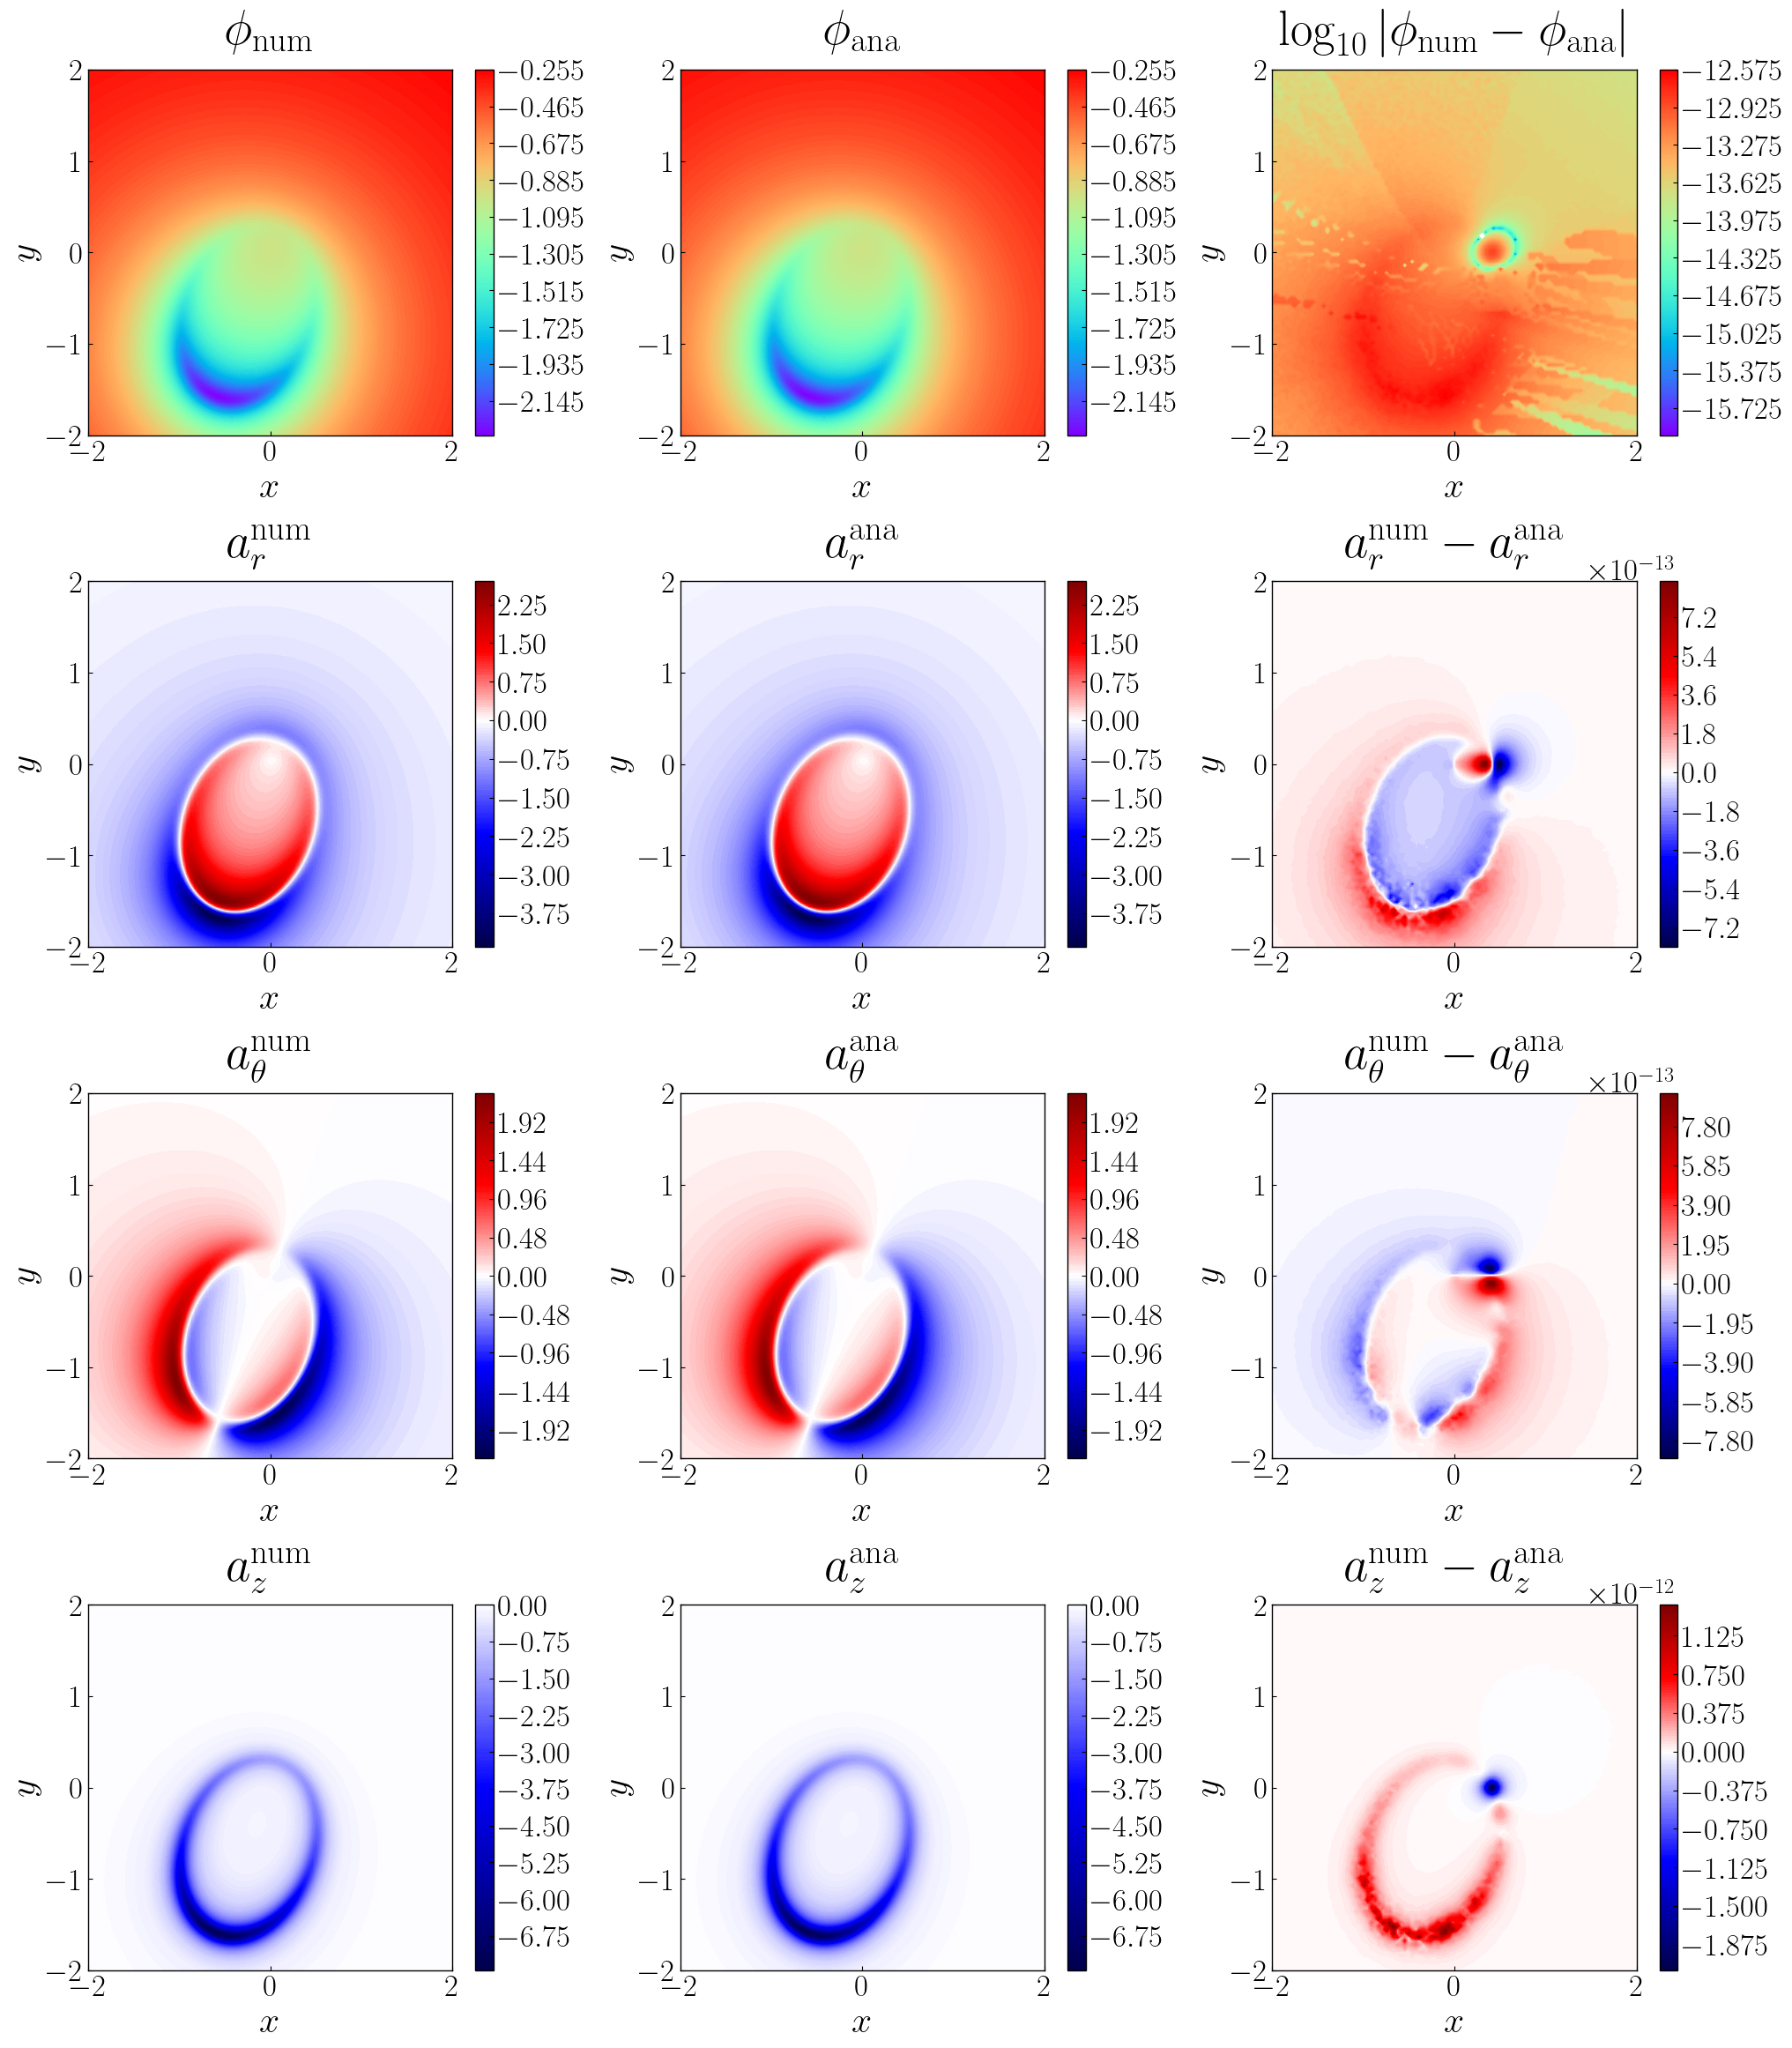

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(24, 28))
fig.subplots_adjust(wspace=0.3, hspace=0.4)

axes[0, 0].set_title(r"$\phi_{\mathrm{num}}$")
im0 = axes[0, 0].contourf(X, Y, phi_num_vals, 150, cmap='rainbow')
fig.colorbar(im0, ax=axes[0, 0])

axes[0, 1].set_title(r"$\phi_{\mathrm{ana}}$")
im1 = axes[0, 1].contourf(X, Y, phi_ana_vals, 150, cmap='rainbow')
fig.colorbar(im1, ax=axes[0, 1])

axes[0, 2].set_title(r"$\log_{10}|\phi_{\mathrm{num}} - \phi_{\mathrm{ana}}|$")
a = np.log10(np.abs(phi_num_vals - phi_ana_vals))
im2 = axes[0, 2].contourf(X, Y, a, 150, cmap='rainbow')
fig.colorbar(im2, ax=axes[0, 2])

axes[1, 0].set_title(r"$a_r^{\mathrm{num}}$")
norm_ar_num = TwoSlopeNorm(vmin=np.min(ar_num), vcenter=0, vmax=np.max(ar_num))
im3 = axes[1, 0].contourf(X, Y, ar_num, 150, cmap='seismic', norm=norm_ar_num)
fig.colorbar(im3, ax=axes[1, 0])

axes[1, 1].set_title(r"$a_r^{\mathrm{ana}}$")
norm_ar_ana = TwoSlopeNorm(vmin=np.min(ar_ana), vcenter=0, vmax=np.max(ar_ana))
im4 = axes[1, 1].contourf(X, Y, ar_ana, 150, cmap='seismic', norm=norm_ar_ana)
fig.colorbar(im4, ax=axes[1, 1])

axes[1, 2].set_title(r"$a_r^{\mathrm{num}} - a_r^{\mathrm{ana}}$")
diff_ar = ar_num - ar_ana
norm_diff_ar = TwoSlopeNorm(vmin=np.min(diff_ar), vcenter=0, vmax=np.max(diff_ar))
im5 = axes[1, 2].contourf(X, Y, diff_ar, 150, cmap='seismic', norm=norm_diff_ar)
fig.colorbar(im5, ax=axes[1, 2])

axes[2, 0].set_title(r"$a_\theta^{\mathrm{num}}$")
norm_atheta_num = TwoSlopeNorm(vmin=np.min(atheta_num), vcenter=0, vmax=np.max(atheta_num))
im6 = axes[2, 0].contourf(X, Y, atheta_num, 150, cmap='seismic', norm=norm_atheta_num)
fig.colorbar(im6, ax=axes[2, 0])

axes[2, 1].set_title(r"$a_\theta^{\mathrm{ana}}$")
norm_atheta_ana = TwoSlopeNorm(vmin=np.min(atheta_ana), vcenter=0, vmax=np.max(atheta_ana))
im7 = axes[2, 1].contourf(X, Y, atheta_ana, 150, cmap='seismic', norm=norm_atheta_ana)
fig.colorbar(im7, ax=axes[2, 1])

axes[2, 2].set_title(r"$a_\theta^{\mathrm{num}} - a_\theta^{\mathrm{ana}}$")
diff_atheta = atheta_num - atheta_ana
norm_diff_atheta = TwoSlopeNorm(vmin=np.min(diff_atheta), vcenter=0, vmax=np.max(diff_atheta))
im8 = axes[2, 2].contourf(X, Y, diff_atheta, 150, cmap='seismic', norm=norm_diff_atheta)
fig.colorbar(im8, ax=axes[2, 2])

axes[3, 0].set_title(r"$a_z^{\mathrm{num}}$")
norm_az_num = TwoSlopeNorm(vmin=np.min(az_num), vcenter=0, vmax=-np.min(az_num))
im9 = axes[3, 0].contourf(X, Y, az_num, 150, cmap='seismic', norm=norm_az_num)
fig.colorbar(im9, ax=axes[3, 0])

axes[3, 1].set_title(r"$a_z^{\mathrm{ana}}$")
norm_az_ana = TwoSlopeNorm(vmin=np.min(az_ana), vcenter=0, vmax=-np.min(az_ana))
im10 = axes[3, 1].contourf(X, Y, az_ana, 150, cmap='seismic', norm=norm_az_ana)
fig.colorbar(im10, ax=axes[3, 1])

axes[3, 2].set_title(r"$a_z^{\mathrm{num}} - a_z^{\mathrm{ana}}$")
diff_az = az_num - az_ana
norm_diff_az = TwoSlopeNorm(vmin=np.min(diff_az), vcenter=0, vmax=np.max(diff_az))
im11 = axes[3, 2].contourf(X, Y, diff_az, 150, cmap='seismic', norm=norm_diff_az)
fig.colorbar(im11, ax=axes[3, 2])

for ax in axes.flat:
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

plt.savefig("planetary_eccentric_ring_plot.png", dpi=300, bbox_inches="tight")
